# PPO from scratch for beam tracking

This notebook trains a PPO agent without Stable-Baselines. Tune the parameter block below, then run the training and evaluation cells. Evaluation episodes are recorded to disk for later UE movement, beam tracking, SNR, outage, and reward visualization.

In [1]:
# All tunable parameters live here.
PARAMS = {
    "seed": 7,
    "scenario_name": "single_occluder",
    "max_steps": 192,
    "hist_len": 5,
    "num_beams": 13,
    "total_timesteps": 30_000,
    "rollout_steps": 512,
    "update_epochs": 8,
    "minibatch_size": 128,
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_coef": 0.20,
    "ent_coef": 0.01,
    "vf_coef": 0.50,
    "max_grad_norm": 0.50,
    "hidden_sizes": (128, 128),
    "device": "cpu",  # change to "cuda" if available and desired
    "eval_episodes": 3,
    "record_training_data": False,
    "record_eval_data": True,
    "data_root": "recordings/ppo_from_scratch",
}

CHANNEL_PARAMS = {
    "snr_ref_db": 30.0,
    "d0": 100.0,
    "path_loss_exp": 2.2,
    "blockage_loss_db": 22.0,
    "beam_3db_deg": 10.0,
}

REWARD_PARAMS = {
    "outage_thresh_db": 5.0,
    "snr_weight": 1.0,
    "outage_weight": 1.0,
    "switch_weight": 0.02,
}

MOVEMENT_PARAMS = {
    "model": "stochastic",
    "speed_mean": 4.0,
    "speed_std": 0.5,
    "heading_std_deg": 8.0,
    "velocity_damping": 0.85,
    "min_speed": 0.25,
    "max_speed": 8.0,
    "position_noise_std": 0.0,
    "reflect_at_bounds": True,
}

assert PARAMS["rollout_steps"] >= PARAMS["minibatch_size"]
assert PARAMS["rollout_steps"] % PARAMS["minibatch_size"] == 0

In [2]:
from __future__ import annotations

import csv
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.distributions.categorical import Categorical
import torch.nn.functional as F

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "beam_tracker_rl").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_tracker_rl import BeamTrackingEnv, ChannelConfig, MovementConfig, RewardConfig

random.seed(PARAMS["seed"])
np.random.seed(PARAMS["seed"])
torch.manual_seed(PARAMS["seed"])
device = torch.device(PARAMS["device"])


def make_env(*, record: bool, run_name: str) -> BeamTrackingEnv:
    return BeamTrackingEnv(
        scenario_name=PARAMS["scenario_name"],
        max_steps=PARAMS["max_steps"],
        hist_len=PARAMS["hist_len"],
        num_beams=PARAMS["num_beams"],
        channel_config=ChannelConfig(**CHANNEL_PARAMS),
        reward_config=RewardConfig(**REWARD_PARAMS),
        movement_config=MovementConfig(**MOVEMENT_PARAMS),
        data_dir=Path(PARAMS["data_root"]) if record else None,
        run_name=run_name,
    )

In [3]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden_sizes: tuple[int, ...]):
        super().__init__()
        layers: list[nn.Module] = []
        last_dim = obs_dim
        for hidden_dim in hidden_sizes:
            layers.extend((nn.Linear(last_dim, hidden_dim), nn.Tanh()))
            last_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)
        self.policy_head = nn.Linear(last_dim, n_actions)
        self.value_head = nn.Linear(last_dim, 1)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0.0)
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)

    def forward(self, obs: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        features = self.backbone(obs)
        return self.policy_head(features), self.value_head(features).squeeze(-1)

    def get_action_and_value(
        self, obs: torch.Tensor, action: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        logits, value = self(obs)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value

In [4]:
train_env = make_env(record=PARAMS["record_training_data"], run_name="ppo_scratch_train")
train_env.action_space.seed(PARAMS["seed"])
obs_np, _ = train_env.reset(seed=PARAMS["seed"])

obs_dim = int(np.prod(train_env.observation_space.shape))
n_actions = int(train_env.action_space.n)
agent = ActorCritic(obs_dim, n_actions, PARAMS["hidden_sizes"]).to(device)
optimizer = torch.optim.Adam(agent.parameters(), lr=PARAMS["learning_rate"], eps=1e-5)

episode_returns: list[float] = []
loss_history: list[dict[str, float]] = []
current_episode_return = 0.0
global_step = 0
last_done = False
update_idx = 0

while global_step < PARAMS["total_timesteps"]:
    rollout_steps = min(PARAMS["rollout_steps"], PARAMS["total_timesteps"] - global_step)
    obs_buf = torch.zeros((rollout_steps, obs_dim), dtype=torch.float32, device=device)
    actions_buf = torch.zeros(rollout_steps, dtype=torch.long, device=device)
    logprobs_buf = torch.zeros(rollout_steps, dtype=torch.float32, device=device)
    rewards_buf = torch.zeros(rollout_steps, dtype=torch.float32, device=device)
    dones_buf = torch.zeros(rollout_steps, dtype=torch.float32, device=device)
    values_buf = torch.zeros(rollout_steps, dtype=torch.float32, device=device)

    for step in range(rollout_steps):
        obs_tensor = torch.as_tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(obs_tensor)

        next_obs, reward, terminated, truncated, _ = train_env.step(int(action.item()))
        done = bool(terminated or truncated)

        obs_buf[step] = obs_tensor.squeeze(0)
        actions_buf[step] = action.squeeze(0)
        logprobs_buf[step] = logprob.squeeze(0)
        rewards_buf[step] = float(reward)
        dones_buf[step] = float(done)
        values_buf[step] = value.squeeze(0)

        current_episode_return += float(reward)
        global_step += 1
        last_done = done
        if done:
            episode_returns.append(current_episode_return)
            current_episode_return = 0.0
            next_obs, _ = train_env.reset()
        obs_np = next_obs

    with torch.no_grad():
        next_obs_tensor = torch.as_tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
        _, next_value = agent(next_obs_tensor)
        next_value = next_value.squeeze(0)

    advantages = torch.zeros_like(rewards_buf, device=device)
    last_gae = torch.tensor(0.0, device=device)
    for t in reversed(range(rollout_steps)):
        if t == rollout_steps - 1:
            next_nonterminal = 1.0 - float(last_done)
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones_buf[t]
            next_values = values_buf[t + 1]
        delta = rewards_buf[t] + PARAMS["gamma"] * next_values * next_nonterminal - values_buf[t]
        last_gae = delta + PARAMS["gamma"] * PARAMS["gae_lambda"] * next_nonterminal * last_gae
        advantages[t] = last_gae
    returns = advantages + values_buf

    batch_indices = np.arange(rollout_steps)
    pg_losses = []
    value_losses = []
    entropy_losses = []
    for _ in range(PARAMS["update_epochs"]):
        np.random.shuffle(batch_indices)
        for start in range(0, rollout_steps, PARAMS["minibatch_size"]):
            mb_idx = batch_indices[start : start + PARAMS["minibatch_size"]]
            _, new_logprob, entropy, new_value = agent.get_action_and_value(
                obs_buf[mb_idx], actions_buf[mb_idx]
            )
            logratio = new_logprob - logprobs_buf[mb_idx]
            ratio = logratio.exp()
            mb_advantages = advantages[mb_idx]
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)
            pg_loss_1 = -mb_advantages * ratio
            pg_loss_2 = -mb_advantages * torch.clamp(
                ratio, 1.0 - PARAMS["clip_coef"], 1.0 + PARAMS["clip_coef"]
            )
            pg_loss = torch.max(pg_loss_1, pg_loss_2).mean()
            value_loss = F.mse_loss(new_value, returns[mb_idx])
            entropy_loss = entropy.mean()
            loss = pg_loss - PARAMS["ent_coef"] * entropy_loss + PARAMS["vf_coef"] * value_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), PARAMS["max_grad_norm"])
            optimizer.step()

            pg_losses.append(float(pg_loss.detach().cpu()))
            value_losses.append(float(value_loss.detach().cpu()))
            entropy_losses.append(float(entropy_loss.detach().cpu()))

    update_idx += 1
    recent_return = np.mean(episode_returns[-10:]) if episode_returns else float("nan")
    loss_history.append(
        {
            "step": global_step,
            "policy_loss": float(np.mean(pg_losses)),
            "value_loss": float(np.mean(value_losses)),
            "entropy": float(np.mean(entropy_losses)),
            "mean_return_10": float(recent_return),
        }
    )
    print(
        f"update={update_idx:03d} step={global_step:06d} "
        f"mean_return_10={recent_return:8.3f} "
        f"policy_loss={loss_history[-1]['policy_loss']:8.4f} "
        f"value_loss={loss_history[-1]['value_loss']:8.4f}"
    )

train_env.close()

update=001 step=000512 mean_return_10=-297.305 policy_loss= -0.0120 value_loss=549.0548
update=002 step=001024 mean_return_10=-298.185 policy_loss= -0.0122 value_loss=463.6039
update=003 step=001536 mean_return_10=-297.834 policy_loss= -0.0125 value_loss=472.7055
update=004 step=002048 mean_return_10=-294.933 policy_loss= -0.0084 value_loss=435.1556
update=005 step=002560 mean_return_10=-291.260 policy_loss= -0.0090 value_loss=375.0849
update=006 step=003072 mean_return_10=-289.061 policy_loss= -0.0121 value_loss=435.2495
update=007 step=003584 mean_return_10=-287.754 policy_loss= -0.0062 value_loss=417.3837
update=008 step=004096 mean_return_10=-284.775 policy_loss= -0.0138 value_loss=365.6096
update=009 step=004608 mean_return_10=-284.688 policy_loss= -0.0161 value_loss=381.0054
update=010 step=005120 mean_return_10=-284.968 policy_loss= -0.0150 value_loss=419.5063
update=011 step=005632 mean_return_10=-287.677 policy_loss= -0.0113 value_loss=339.1609
update=012 step=006144 mean_retu

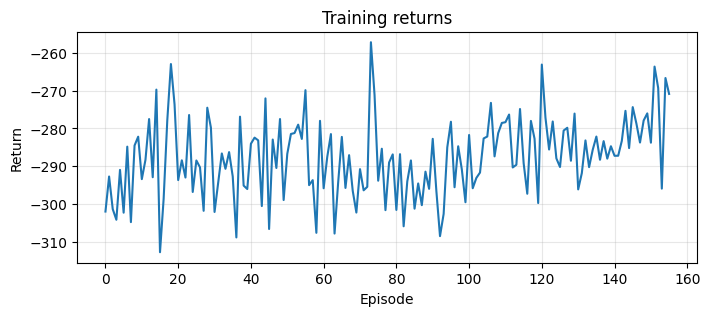

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Training returns")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
@torch.no_grad()
def greedy_action(obs: np.ndarray) -> int:
    obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    logits, _ = agent(obs_tensor)
    return int(torch.argmax(logits, dim=-1).item())


eval_env = make_env(record=PARAMS["record_eval_data"], run_name="ppo_scratch_eval")
eval_returns = []
for episode in range(PARAMS["eval_episodes"]):
    obs, _ = eval_env.reset(seed=PARAMS["seed"] + 1_000 + episode)
    done = False
    episode_return = 0.0
    while not done:
        obs, reward, terminated, truncated, _ = eval_env.step(greedy_action(obs))
        episode_return += float(reward)
        done = bool(terminated or truncated)
    eval_returns.append(episode_return)

eval_env.close()
print(f"eval_returns={eval_returns}")
print(f"recording_dir={eval_env.run_dir}")

eval_returns=[-252.9030227650351, -252.9030227650351, -252.9030227650351]
recording_dir=recordings/ppo_from_scratch/ppo_scratch_eval_20260425_132755_189654


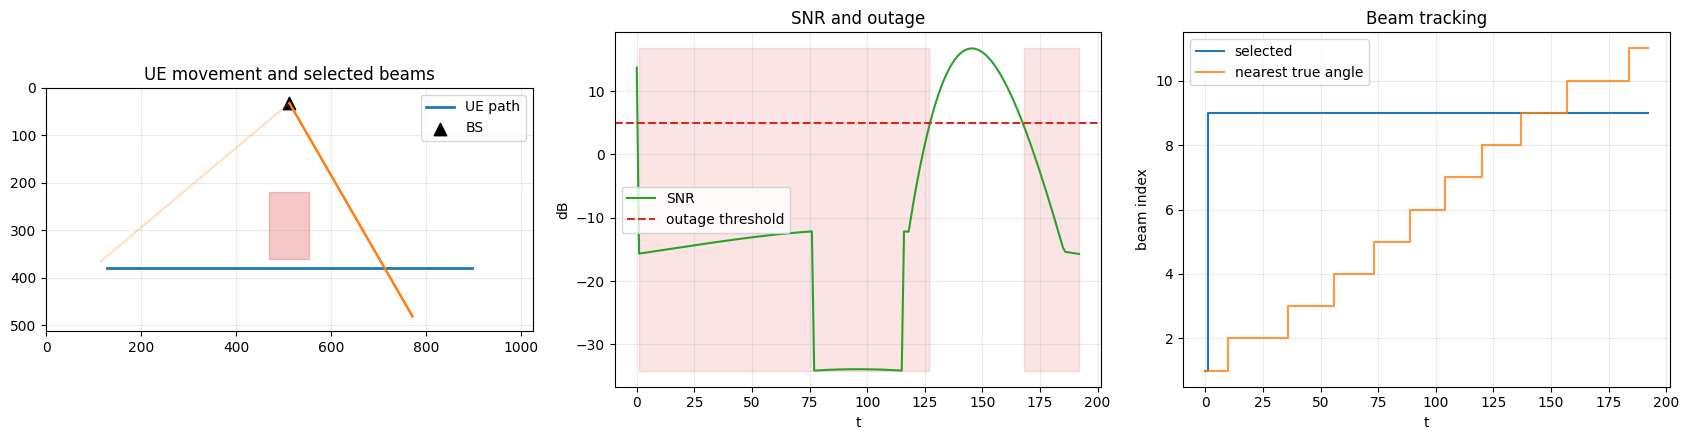

In [8]:
def load_episode_csv(path: Path) -> dict[str, list[float]]:
    with path.open(newline="", encoding="utf-8") as file:
        rows = list(csv.DictReader(file))
    numeric: dict[str, list[float]] = {key: [] for key in rows[0]}
    for row in rows:
        for key, value in row.items():
            if value in {"True", "False"}:
                numeric[key].append(float(value == "True"))
            else:
                numeric[key].append(float(value))
    return numeric


if eval_env.run_dir is not None:
    episode_dirs = sorted(eval_env.run_dir.glob("episode_*"))
    steps_path = episode_dirs[-1] / "steps.csv"
    data = load_episode_csv(steps_path)
    world = eval_env.get_static_world()

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    ax = axes[0]
    ax.plot(data["ue_x"], data["ue_y"], color="tab:blue", linewidth=2, label="UE path")
    ax.scatter([data["bs_x"][0]], [data["bs_y"][0]], color="black", marker="^", s=80, label="BS")
    for obstacle in world["obstacles"]:
        rect = plt.Rectangle(
            (obstacle["x"], obstacle["y"]), obstacle["w"], obstacle["h"],
            color="tab:red", alpha=0.25
        )
        ax.add_patch(rect)
    for idx in range(0, len(data["t"]), max(1, len(data["t"]) // 12)):
        theta = np.deg2rad(data["selected_beam_deg"][idx])
        length = max(data["distance"])
        x0, y0 = data["bs_x"][idx], data["bs_y"][idx]
        ax.plot([x0, x0 + length * np.sin(theta)], [y0, y0 + length * np.cos(theta)], color="tab:orange", alpha=0.25)
    ax.set_title("UE movement and selected beams")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0, world["width"])
    ax.set_ylim(world["height"], 0)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)

    axes[1].plot(data["t"], data["snr_db"], color="tab:green", label="SNR")
    axes[1].axhline(REWARD_PARAMS["outage_thresh_db"], color="tab:red", linestyle="--", label="outage threshold")
    axes[1].fill_between(data["t"], min(data["snr_db"]), max(data["snr_db"]), where=np.array(data["outage"]) > 0, color="tab:red", alpha=0.12)
    axes[1].set_title("SNR and outage")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("dB")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)

    axes[2].step(data["t"], data["selected_beam_idx"], where="post", label="selected")
    axes[2].step(data["t"], data["optimal_beam_idx"], where="post", label="nearest true angle", alpha=0.8)
    axes[2].set_title("Beam tracking")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("beam index")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("Set PARAMS['record_eval_data'] = True to create visualization data.")